In [9]:
from single_qubit_rcs import SingleQubitRCS

In [10]:
rcs = SingleQubitRCS(mode='clifford', seed=42)
rcs.verify_all()                          # ensure clifford single qubit operations are implemented correctly
results = rcs.sweep([10, 50, 100, 200])   # single layer of clifford single qubit gate RCS

gate     init    p0_mbqc  p0_direct      TVD
---------------------------------------------
√X       |0>       0.507      0.496   0.0117
√X       |1>       0.516      0.482   0.0337
√X       |+>       0.520      0.509   0.0103
√Y       |0>       0.503      0.506   0.0029
√Y       |1>       0.502      0.500   0.0020
√Y       |+>       0.000      0.000   0.0000
---------------------------------------------
Max TVD: 0.0337  (expected ~0 within shot noise)
    N  depth   qubits      t_MBQC    t_direct   mean TVD   max TVD
----------------------------------------------------------------------
   10      1       20     0.436s     0.447s     0.0186    0.0332
   50      1      100     0.505s     0.509s     0.0258    0.0879
  100      1      200     0.676s     0.489s     0.0248    0.1074
  200      1      400     1.342s     0.519s     0.0228    0.0977


In [11]:
rcs.sweep([10, 50, 100], depth=5)

    N  depth   qubits      t_MBQC    t_direct   mean TVD   max TVD
----------------------------------------------------------------------
   10      5       20     0.470s     0.445s     0.0160    0.0352
   50      5      100     0.876s     0.533s     0.0164    0.0645
  100      5      200     1.873s     0.487s     0.0166    0.0801


[{'n': 10,
  'depth': 5,
  'qubits_mbqc': 20,
  't_mbqc': 0.46954345703125,
  't_direct': 0.44518423080444336,
  'speedup': 1.0547171812056095,
  'tvd_mean': 0.016015625,
  'tvd_max': 0.03515625,
  'gates': [['sqrt_Y',
    'sqrt_Y',
    'sqrt_X',
    'sqrt_Y',
    'sqrt_X',
    'sqrt_Y',
    'sqrt_X',
    'sqrt_X',
    'sqrt_X',
    'sqrt_Y'],
   ['sqrt_X',
    'sqrt_Y',
    'sqrt_X',
    'sqrt_X',
    'sqrt_Y',
    'sqrt_X',
    'sqrt_Y',
    'sqrt_Y',
    'sqrt_X',
    'sqrt_X'],
   ['sqrt_X',
    'sqrt_Y',
    'sqrt_Y',
    'sqrt_X',
    'sqrt_X',
    'sqrt_X',
    'sqrt_X',
    'sqrt_Y',
    'sqrt_Y',
    'sqrt_X'],
   ['sqrt_Y',
    'sqrt_X',
    'sqrt_X',
    'sqrt_Y',
    'sqrt_Y',
    'sqrt_Y',
    'sqrt_X',
    'sqrt_X',
    'sqrt_X',
    'sqrt_X'],
   ['sqrt_Y',
    'sqrt_Y',
    'sqrt_X',
    'sqrt_Y',
    'sqrt_X',
    'sqrt_Y',
    'sqrt_X',
    'sqrt_X',
    'sqrt_Y',
    'sqrt_X']],
  'mbqc_counts': {'1010000100': 12,
   '1000000100': 5,
   '0000100000': 9,
   '001011010

In [12]:
# Non-Clifford mode → statevector
rcs_nc = SingleQubitRCS(mode='supremacy', seed=42)
rcs_nc.verify_all()
rcs_nc.sweep([2, 4, 8])

gate     init    p0_mbqc  p0_direct      TVD
---------------------------------------------
√X       |0>       0.509      0.523   0.0146
√X       |1>       0.516      0.495   0.0210
√X       |+>       0.499      0.504   0.0054
√Y       |0>       0.518      0.502   0.0156
√Y       |1>       0.500      0.498   0.0015
√Y       |+>       0.000      0.000   0.0000
√W       |0>       0.493      0.481   0.0112
√W       |1>       0.508      0.498   0.0098
√W       |+>       0.143      0.162   0.0186
---------------------------------------------
Max TVD: 0.0210  (expected ~0 within shot noise)
    N  depth   qubits      t_MBQC    t_direct   mean TVD   max TVD
----------------------------------------------------------------------
    2      1        4     0.106s     0.108s     0.0244    0.0273
    4      1        8     0.126s     0.108s     0.0347    0.0488
    8      1       16     4.139s     0.078s     0.0193    0.0410


[{'n': 2,
  'depth': 1,
  'qubits_mbqc': 4,
  't_mbqc': 0.1056215763092041,
  't_direct': 0.10814452171325684,
  'speedup': 0.9766706129530789,
  'tvd_mean': 0.0244140625,
  'tvd_max': 0.02734375,
  'gates': [['sqrt_X', 'sqrt_W']],
  'mbqc_counts': {'00': 123, '11': 112, '10': 141, '01': 136},
  'direct_counts': {'00': 138, '01': 135, '11': 124, '10': 115}},
 {'n': 4,
  'depth': 1,
  'qubits_mbqc': 8,
  't_mbqc': 0.125762939453125,
  't_direct': 0.10759973526000977,
  'speedup': 1.1688034282726132,
  'tvd_mean': 0.03466796875,
  'tvd_max': 0.048828125,
  'gates': [['sqrt_Y', 'sqrt_Y', 'sqrt_Y', 'sqrt_W']],
  'mbqc_counts': {'1110': 22,
   '0010': 30,
   '0000': 26,
   '1111': 38,
   '0100': 47,
   '0110': 35,
   '1101': 38,
   '1001': 37,
   '0011': 30,
   '1011': 23,
   '1010': 32,
   '0101': 28,
   '1100': 31,
   '0111': 33,
   '1000': 36,
   '0001': 26},
  'direct_counts': {'1100': 28,
   '0011': 37,
   '0100': 29,
   '0111': 34,
   '1011': 29,
   '1010': 33,
   '1111': 26,
   '0101

In [13]:
# increase depth for 8 pairs (8 qubits)
for d in [1, 2, 5, 10, 20]:
    r = rcs_nc.run_rcs(n_pairs=8, depth=d)
    print(f"depth={d:3d}  t_mbqc={r['t_mbqc']:.3f}s  t_direct={r['t_direct']:.3f}s  tvd={r['tvd_mean']:.4f}")

depth=  1  t_mbqc=5.477s  t_direct=0.076s  tvd=0.0154
depth=  2  t_mbqc=9.886s  t_direct=0.076s  tvd=0.0100
depth=  5  t_mbqc=22.952s  t_direct=0.074s  tvd=0.0229
depth= 10  t_mbqc=46.867s  t_direct=0.071s  tvd=0.0254
depth= 20  t_mbqc=95.013s  t_direct=0.073s  tvd=0.0244


    N  depth   qubits      t_MBQC    t_direct   mean TVD   max TVD
----------------------------------------------------------------------
   50      1      100     0.481s     0.428s     0.0250    0.0762
  100      1      200     0.757s     0.466s     0.0263    0.0840
  150      1      300     0.906s     0.517s     0.0239    0.1074
  200      1      400     1.334s     0.537s     0.0241    0.0801
  250      1      500     1.795s     0.559s     0.0261    0.0957
  300      1      600     2.298s     0.641s     0.0254    0.0918
  350      1      700     3.141s     0.725s     0.0230    0.0820
  400      1      800     3.756s     0.814s     0.0250    0.1035
  450      1      900     5.018s     0.951s     0.0252    0.1113
  500      1     1000     6.095s     1.055s     0.0237    0.0977
depth=  2  t_mbqc=0.106s  t_direct=0.096s  tvd=0.0083
depth=  4  t_mbqc=0.153s  t_direct=0.104s  tvd=0.0142
depth=  6  t_mbqc=0.201s  t_direct=0.103s  tvd=0.0112
depth=  8  t_mbqc=0.244s  t_direct=0.104s  tvd=0.0

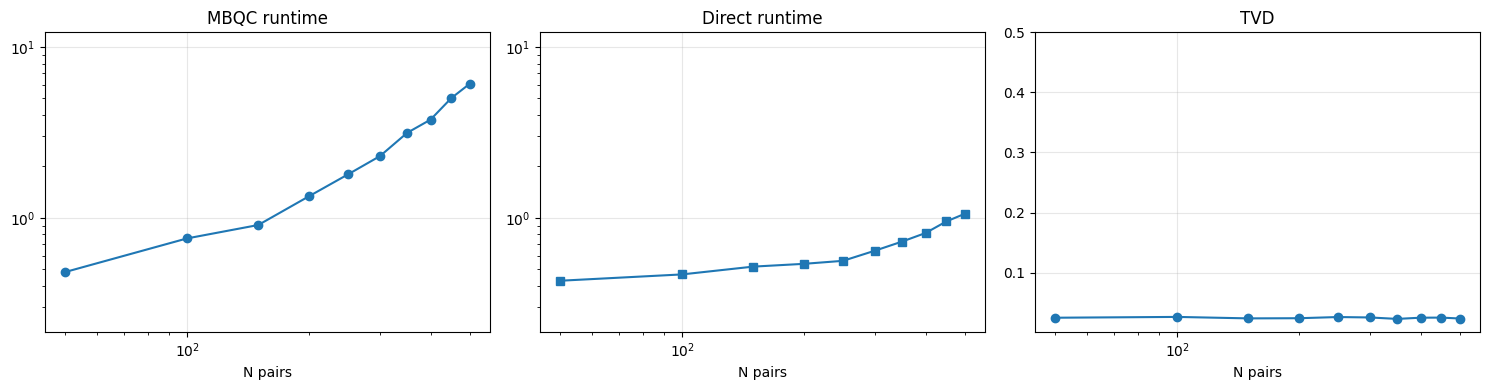

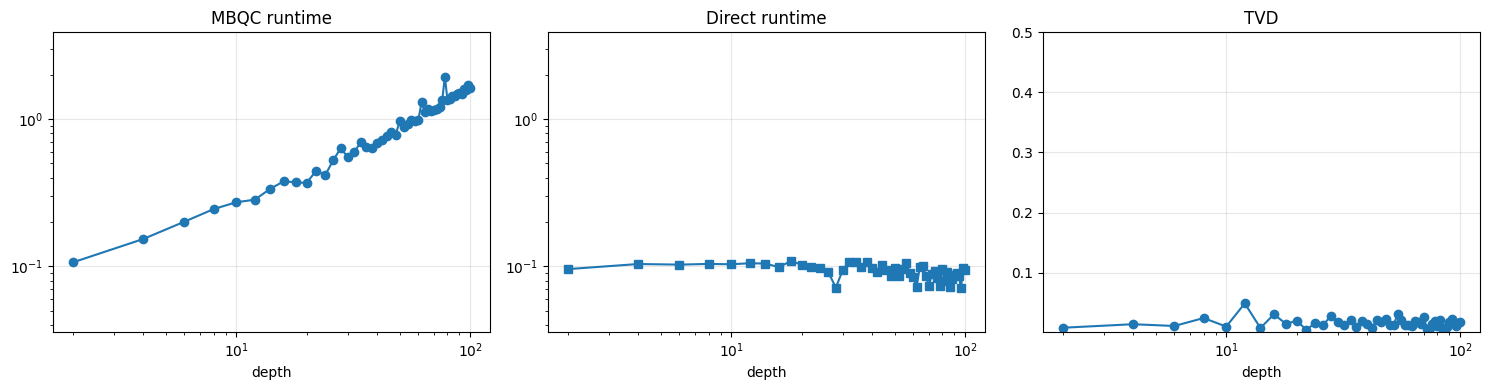

In [14]:
import pickle
import matplotlib.pyplot as plt
import numpy as np

qubit_sweep = list(range(50, 501, 50))
depth_sweep = list(range(2, 102, 2))

# sweep number of qubits (depth 1)
rcs = SingleQubitRCS(mode='clifford', seed=42)
results_q = rcs.sweep(qubit_sweep, depth=1)
pickle.dump(results_q, open('sweep_qubits.pkl', 'wb'))

# sweep depth (4 pairs)
rcs = SingleQubitRCS(mode='supremacy', seed=42)
results_d = [rcs.run_rcs(n_pairs=4, depth=d) for d in depth_sweep]
for d, r in zip(depth_sweep, results_d):
    print(f"depth={d:3d}  t_mbqc={r['t_mbqc']:.3f}s  t_direct={r['t_direct']:.3f}s  tvd={r['tvd_mean']:.4f}")
pickle.dump(results_d, open('sweep_depth.pkl', 'wb'))

# plotting
def plot(results, x_key, x_label):
    xs       = [r[x_key]    for r in results]
    t_mbqc   = [r['t_mbqc']   for r in results]
    t_direct = [r['t_direct'] for r in results]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].loglog(xs, t_mbqc,   'o-'); axes[0].set_title('MBQC runtime')
    axes[1].loglog(xs, t_direct, 's-'); axes[1].set_title('Direct runtime')
    axes[2].semilogx(xs, [r['tvd_mean'] for r in results], 'o-'); axes[2].set_title('TVD')
    axes[2].set_ylim(0.001, 0.5)

    y_lo = min(min(t_mbqc), min(t_direct)) * 0.5
    y_hi = max(max(t_mbqc), max(t_direct)) * 2
    axes[0].set_ylim(y_lo, y_hi)
    axes[1].set_ylim(y_lo, y_hi)

    for ax in axes:
        ax.set_xlabel(x_label); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

plot(pickle.load(open('sweep_qubits.pkl', 'rb')), 'n',     'N pairs')
plot(pickle.load(open('sweep_depth.pkl',  'rb')), 'depth', 'depth')

 depth   joint TVD   per-qubit TVD
------------------------------------
     1      0.0693          0.0308
     2      0.0625          0.0205
     3      0.0654          0.0186
     5      0.0605          0.0107
     7      0.0596          0.0210
    10      0.0723          0.0237
    15      0.0459          0.0107
    20      0.0723          0.0193


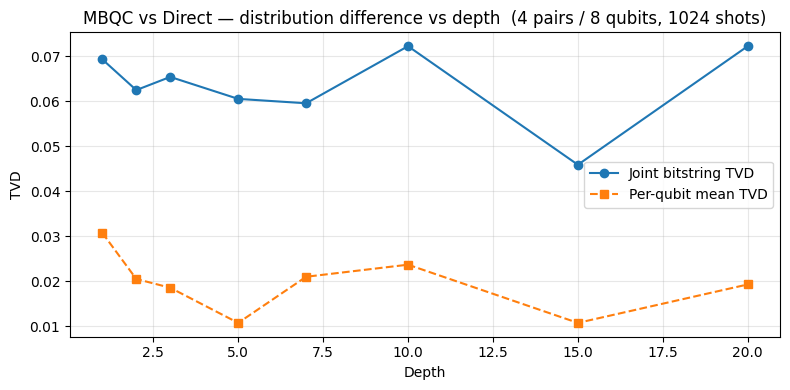

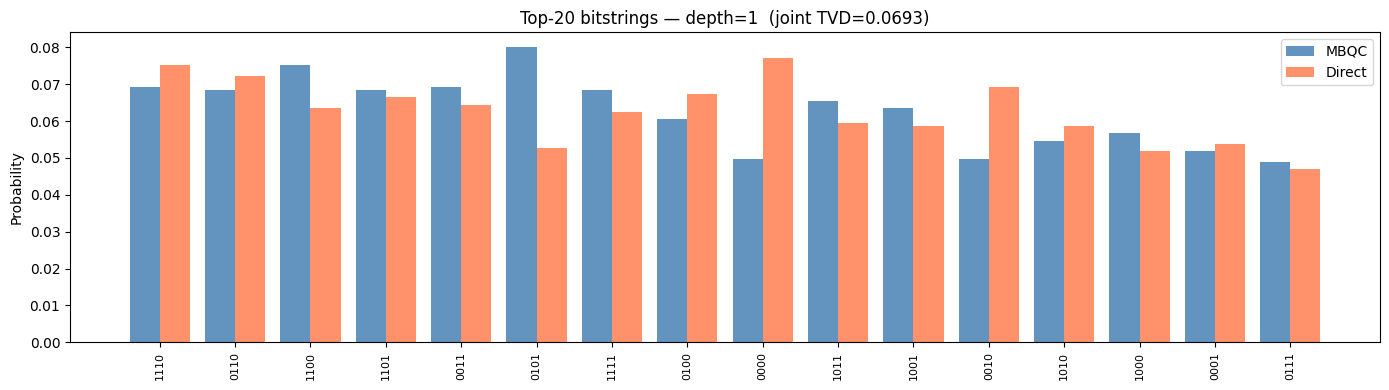

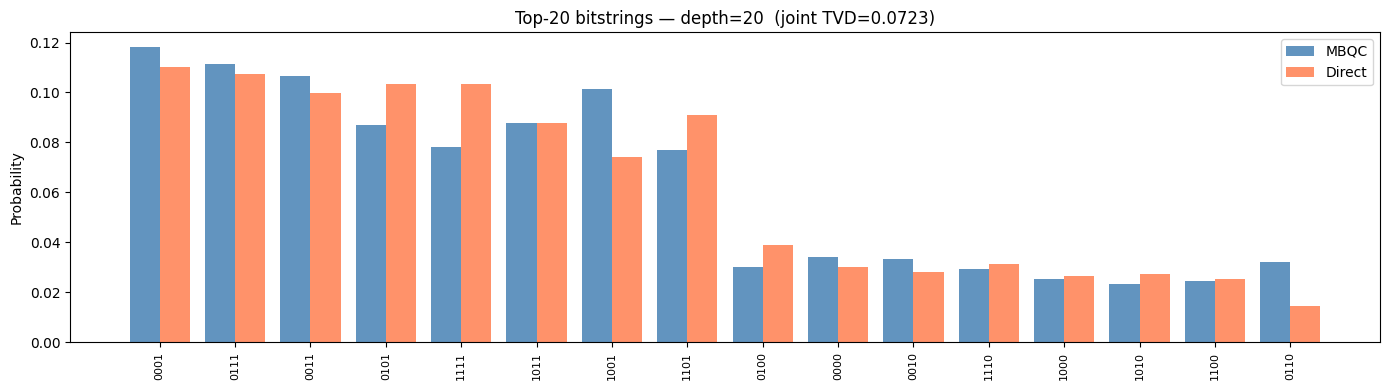

In [15]:
# ── 4×2 qubits: bitstring distribution divergence vs depth ──────────────────
N_PAIRS = 4
SHOTS   = 1024
DEPTHS  = [1, 2, 3, 5, 7, 10, 15, 20]

rcs4 = SingleQubitRCS(mode='supremacy', seed=7)

def joint_tvd(m_counts, d_counts, shots):
    keys = set(m_counts) | set(d_counts)
    return 0.5 * sum(
        abs(m_counts.get(k, 0) / shots - d_counts.get(k, 0) / shots)
        for k in keys
    )

results_4p = []
print(f'{"depth":>6}  {"joint TVD":>10}  {"per-qubit TVD":>14}')
print('-' * 36)
for d in DEPTHS:
    r   = rcs4.run_rcs(n_pairs=N_PAIRS, depth=d, shots=SHOTS)
    tvd = joint_tvd(r['mbqc_counts'], r['direct_counts'], SHOTS)
    r['tvd_joint'] = tvd
    results_4p.append(r)
    print(f'{d:>6d}  {tvd:>10.4f}  {r["tvd_mean"]:>14.4f}')

# ── TVD vs depth ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(DEPTHS, [r['tvd_joint'] for r in results_4p], 'o-',  label='Joint bitstring TVD')
ax.plot(DEPTHS, [r['tvd_mean']  for r in results_4p], 's--', label='Per-qubit mean TVD')
ax.set_xlabel('Depth')
ax.set_ylabel('TVD')
ax.set_title(f'MBQC vs Direct — distribution difference vs depth  '
             f'({N_PAIRS} pairs / {N_PAIRS*2} qubits, {SHOTS} shots)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── Bitstring distributions at depth=1 and depth=max ────────────────────────
TOP_N = 20
for r in [results_4p[0], results_4p[-1]]:
    m, dc = r['mbqc_counts'], r['direct_counts']
    top_keys = sorted(
        set(m) | set(dc),
        key=lambda k: m.get(k, 0) + dc.get(k, 0),
        reverse=True,
    )[:TOP_N]

    x, w = np.arange(len(top_keys)), 0.4
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.bar(x - w/2, [m.get(k,  0) / SHOTS for k in top_keys], w,
           label='MBQC',   color='steelblue', alpha=0.85)
    ax.bar(x + w/2, [dc.get(k, 0) / SHOTS for k in top_keys], w,
           label='Direct', color='coral',     alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(top_keys, rotation=90, fontsize=8)
    ax.set_ylabel('Probability')
    ax.set_title(f'Top-{TOP_N} bitstrings — depth={r["depth"]}  '
                 f'(joint TVD={r["tvd_joint"]:.4f})')
    ax.legend()
    plt.tight_layout()
    plt.show()